In [8]:
%pip install pandas numpy scipy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\shamim.msas.7\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import os
import textwrap
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Output directories
os.makedirs("../data/cleaned", exist_ok=True)
os.makedirs("../outputs/figures/phase1", exist_ok=True)
os.makedirs("../outputs/tables/phase1", exist_ok=True)

# 1. Read raw data
df = pd.read_csv("../data/raw/survey1.csv")

print("Raw data shape:", df.shape)


Raw data shape: (118, 19)


In [10]:
# =========================================================================
# 2. DATA CLEANING AND PREPARATION
# =========================================================================

# Extract relevant columns by positional index
col_role = df.columns[2]         # Role (Student / Teacher)
col_uni = df.columns[4]          # University name/location column
col_q7 = df.columns[8]            # Q7: Platform count / channels
col_q8 = df.columns[9]            # Q8: App switching frequency
tlx_cols = df.columns[10:16]      # Q9-Q14: NASA-TLX dimensions
col_miss_freq = df.columns[16]    # Q15: Missed deadline frequency
col_miss_agree = df.columns[17]   # Q16: Spread perception

tlx_names = ['Mental Demand', 'Physical Demand', 'Temporal Demand',
             'Performance', 'Effort', 'Frustration']

# Clean numeric scales & calculate Overall NASA-TLX
for col in tlx_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['Overall_NASA_TLX'] = df[tlx_cols].mean(axis=1)

# Map ordinal categorical items to numerical values
freq_map = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4}
agree_map = {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5}
q8_map = {'0-2 times': 1, '3-5 times': 2, '6-10 times': 3, '11+ times': 4}

df['q8_num'] = df[col_q8].map(q8_map)
df['miss_freq_num'] = df[col_miss_freq].map(freq_map)
df['miss_agree_num'] = df[col_miss_agree].map(agree_map)

# Define Q7 Binary IV: Single Channel (1) vs. Multi-Channel (2+)
df['q7_binary'] = df[col_q7].apply(
    lambda x: 'Single Channel (1)' if str(x).strip() == '1' else 'Multi Channel (2+)'
)

# University Standardizer
def clean_uni(text):
    if pd.isna(text):
        return "Other / Unspecified"
    t = str(text).strip().lower()
    if 'brac' in t:
        return 'BRAC University'
    elif 'kuet' in t:
        return 'KUET'
    elif 'uiu' in t or 'united' in t:
        return 'United International Univ.'
    elif 'du' in t or 'dhaka' in t:
        return 'Univ. of Dhaka'
    elif 'nsu' in t or 'north south' in t:
        return 'North South Univ.'
    elif 'buet' in t:
        return 'BUET'
    elif 'aust' in t:
        return 'AUST'
    else:
        return 'Other External Univ.'

df['uni_clean'] = df[col_uni].apply(clean_uni)

# Define target sample groups according to methodology
all_df = df.copy()  # All respondents for RQ1 (Workload)
stu_df = df[df[col_role].astype(str).str.strip().str.lower() == 'student'].copy()  # Students only for RQ2

# Save cleaned dataset
df.to_csv("../data/cleaned/survey1_cleaned.csv", index=False)

print("Cleaned data saved to: ../data/cleaned/survey1_cleaned.csv")
print("Cleaned data shape:", df.shape)


Cleaned data saved to: ../data/cleaned/survey1_cleaned.csv
Cleaned data shape: (118, 25)


In [11]:
# =========================================================================
# 3. CONSISTENCY / RELIABILITY ANALYSIS
# =========================================================================

def calculate_cronbach(df_items):
    """Calculates Raw Alpha, Standardized Alpha, and Average Inter-Item Correlation."""
    clean_df = df_items.dropna()
    k = clean_df.shape[1]

    item_vars = clean_df.var(axis=0, ddof=1).sum()
    total_var = clean_df.sum(axis=1).var(ddof=1)
    alpha_raw = (k / (k - 1)) * (1 - (item_vars / total_var))

    corr_matrix = clean_df.corr()
    mean_r = (corr_matrix.values.sum() - k) / (k * (k - 1))
    alpha_std = (k * mean_r) / (1 + (k - 1) * mean_r)

    return alpha_raw, alpha_std, mean_r

# RQ1 Reliability: NASA-TLX Workload (6 Items, All Respondents)
rq1_data = all_df[tlx_cols].rename(columns=dict(zip(tlx_cols, tlx_names)))
rq1_raw, rq1_std, rq1_r = calculate_cronbach(rq1_data)

# RQ2 Reliability: Missed Information (2 Items, Students)
rq2_cols = ['miss_freq_num', 'miss_agree_num']
rq2_data = stu_df[rq2_cols].rename(columns={
    'miss_freq_num': 'Missed Deadline Freq',
    'miss_agree_num': 'Spread Perception'
})
rq2_raw, rq2_std, rq2_r = calculate_cronbach(rq2_data)
spearman_brown_rq2 = (2 * rq2_r) / (1 + rq2_r)

reliability_results = pd.DataFrame({
    "Research Question": [
        "RQ1: Workload Construct",
        "RQ1: Workload Construct",
        "RQ1: Workload Construct",
        "RQ2: Missed Information Construct",
        "RQ2: Missed Information Construct",
        "RQ2: Missed Information Construct",
        "RQ2: Missed Information Construct"
    ],
    "Metric": [
        "Cronbach's Alpha",
        "Standardized Alpha",
        "Mean Inter-Item Correlation",
        "Cronbach's Alpha",
        "Standardized Alpha",
        "Inter-Item Pearson Correlation",
        "Spearman-Brown Reliability"
    ],
    "Value": [
        rq1_raw, rq1_std, rq1_r,
        rq2_raw, rq2_std, rq2_r, spearman_brown_rq2
    ],
    "N": [
        len(rq1_data), len(rq1_data), len(rq1_data),
        len(rq2_data), len(rq2_data), len(rq2_data), len(rq2_data)
    ]
})

reliability_results.to_csv(
    "../outputs/tables/phase1/reliability_analysis_results.csv",
    index=False
)

print("\n=========================================================================")
print("  RELIABILITY ANALYSIS RESULTS")
print("=========================================================================")
print(f"\n--- RQ1: Workload Construct (NASA-TLX, 6 Items | N = {len(rq1_data)}) ---")
print(f"Cronbach's Alpha (α):            {rq1_raw:.3f}")
print(f"Standardized Alpha:              {rq1_std:.3f}")
print(f"Mean Inter-Item Correlation:     {rq1_r:.3f}")

print(f"\n--- RQ2: Missed Information Construct (2 Items | N = {len(rq2_data)}) ---")
print(f"Cronbach's Alpha (α):            {rq2_raw:.3f}")
print(f"Standardized Alpha:              {rq2_std:.3f}")
print(f"Inter-Item Pearson Correlation:  {rq2_r:.3f}")
print(f"Spearman-Brown Reliability:      {spearman_brown_rq2:.3f}")



  RELIABILITY ANALYSIS RESULTS

--- RQ1: Workload Construct (NASA-TLX, 6 Items | N = 118) ---
Cronbach's Alpha (α):            0.862
Standardized Alpha:              0.860
Mean Inter-Item Correlation:     0.507

--- RQ2: Missed Information Construct (2 Items | N = 115) ---
Cronbach's Alpha (α):            0.572
Standardized Alpha:              0.588
Inter-Item Pearson Correlation:  0.416
Spearman-Brown Reliability:      0.588



  DESCRIPTIVE DATA RESULTS
                              Measure  Value
                   Total observations    118
                      Total variables     25
                 Student observations    115
                 Teacher observations      3
  Overall NASA-TLX valid observations    118
Overall NASA-TLX missing observations      0


C:\Users\shamim.msas.7\AppData\Local\Temp\ipykernel_13616\328021861.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uni_counts.values, y=wrapped_labels, palette='viridis')


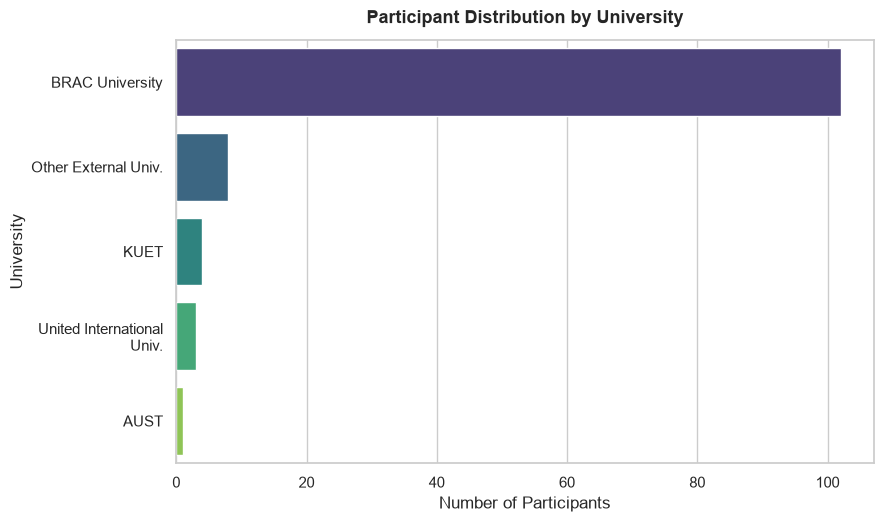

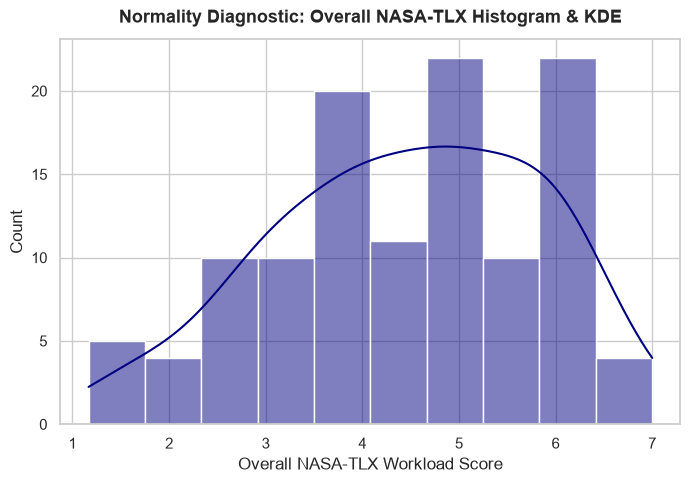

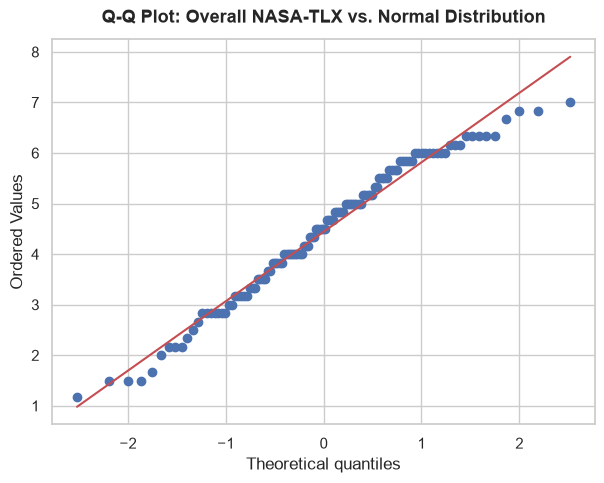

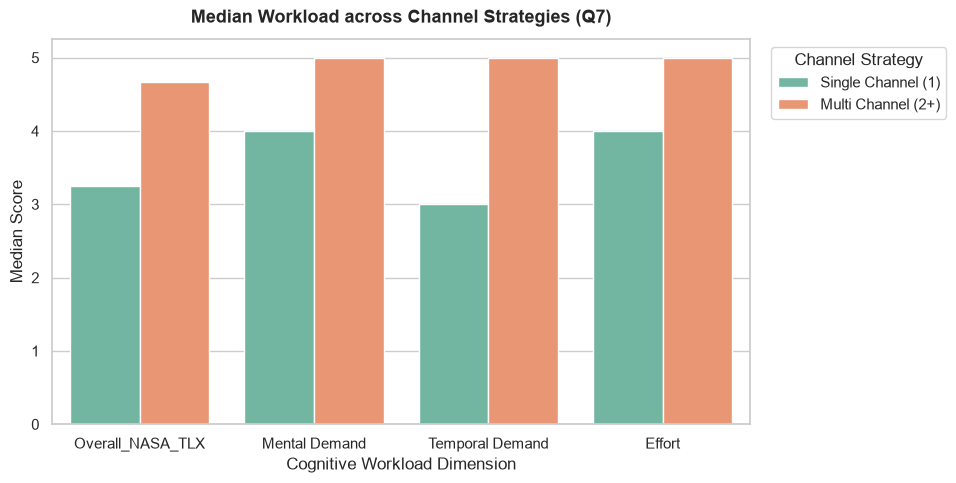

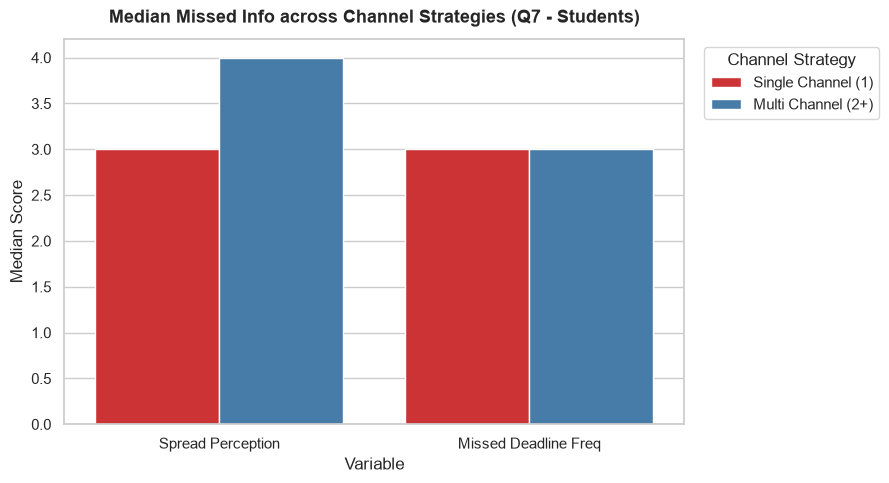

C:\Users\shamim.msas.7\AppData\Local\Temp\ipykernel_13616\328021861.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_q8, y='Overall_NASA_TLX', order=q8_order, palette='Blues')


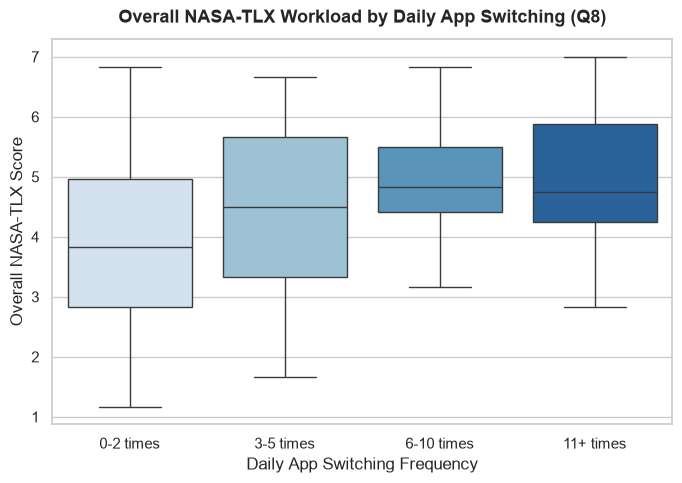

In [12]:
# =========================================================================
# 4. DESCRIPTIVE RESULTS AND DISTRIBUTION / NORMALITY DIAGNOSTICS
# =========================================================================

# Descriptive data shape and completeness
descriptive_results = pd.DataFrame({
    "Measure": [
        "Total observations",
        "Total variables",
        "Student observations",
        "Teacher observations",
        "Overall NASA-TLX valid observations",
        "Overall NASA-TLX missing observations"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        (df[col_role].astype(str).str.strip().str.lower() == 'student').sum(),
        (df[col_role].astype(str).str.strip().str.lower() == 'teacher').sum(),
        df['Overall_NASA_TLX'].notna().sum(),
        df['Overall_NASA_TLX'].isna().sum()
    ]
})

descriptive_results.to_csv(
    "../outputs/tables/phase1/descriptive_data_shape.csv",
    index=False
)

print("\n=========================================================================")
print("  DESCRIPTIVE DATA RESULTS")
print("=========================================================================")
print(descriptive_results.to_string(index=False))

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# DIAGRAM 1: Participant Distribution by University
plt.figure(figsize=(9, 5.5))
uni_counts = df['uni_clean'].value_counts()
wrapped_labels = [textwrap.fill(str(label), width=22) for label in uni_counts.index]

sns.barplot(x=uni_counts.values, y=wrapped_labels, palette='viridis')
plt.title("Participant Distribution by University", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Number of Participants")
plt.ylabel("University")
plt.savefig("../outputs/figures/phase1/1_university_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

uni_counts.rename_axis("University").reset_index(name="Number of Participants").to_csv(
    "../outputs/tables/phase1/university_distribution.csv", index=False
)

# DIAGRAM 2: Normality Check (Histogram + KDE)
plt.figure(figsize=(8, 5))
sns.histplot(df['Overall_NASA_TLX'], kde=True, color='navy', bins=10)
plt.title("Normality Diagnostic: Overall NASA-TLX Histogram & KDE", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Overall NASA-TLX Workload Score")
plt.ylabel("Count")
plt.savefig("../outputs/figures/phase1/2_normality_histogram.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# DIAGRAM 3: Normality Check (Q-Q Plot)
plt.figure(figsize=(7, 5))
stats.probplot(df['Overall_NASA_TLX'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Overall NASA-TLX vs. Normal Distribution", fontsize=13, fontweight='bold', pad=12)
plt.savefig("../outputs/figures/phase1/3_normality_qqplot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# DIAGRAM 4: Workload Dimensions by Channel Strategy (Q7)
plt.figure(figsize=(9, 5))
df_rename = df.rename(columns=dict(zip(tlx_cols, tlx_names)))

q7_melted = pd.melt(
    df_rename,
    id_vars=['q7_binary'],
    value_vars=['Overall_NASA_TLX', 'Mental Demand', 'Temporal Demand', 'Effort'],
    var_name='Dimension',
    value_name='Score'
)
sns.barplot(
    data=q7_melted,
    x='Dimension',
    y='Score',
    hue='q7_binary',
    estimator=np.median,
    errorbar=None,
    palette='Set2'
)
plt.title("Median Workload across Channel Strategies (Q7)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Median Score")
plt.xlabel("Cognitive Workload Dimension")
plt.legend(title="Channel Strategy", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig("../outputs/figures/phase1/4_q7_workload_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# DIAGRAM 5: Missed Info by Channel Strategy (Q7 - Students)
plt.figure(figsize=(8, 5))
q2_melted = pd.melt(
    stu_df,
    id_vars=['q7_binary'],
    value_vars=['miss_agree_num', 'miss_freq_num'],
    var_name='Variable',
    value_name='Score'
)
q2_melted['Variable'] = q2_melted['Variable'].map({
    'miss_agree_num': 'Spread Perception',
    'miss_freq_num': 'Missed Deadline Freq'
})

sns.barplot(
    data=q2_melted,
    x='Variable',
    y='Score',
    hue='q7_binary',
    estimator=np.median,
    errorbar=None,
    palette='Set1'
)
plt.title("Median Missed Info across Channel Strategies (Q7 - Students)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Median Score")
plt.xlabel("Variable")
plt.legend(title="Channel Strategy", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig("../outputs/figures/phase1/5_q7_missed_info.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# DIAGRAM 6: App Switching Frequency vs Workload (Q8 Boxplot)
plt.figure(figsize=(8, 5))
q8_order = ['0-2 times', '3-5 times', '6-10 times', '11+ times']

sns.boxplot(data=df, x=col_q8, y='Overall_NASA_TLX', order=q8_order, palette='Blues')
plt.title("Overall NASA-TLX Workload by Daily App Switching (Q8)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Daily App Switching Frequency")
plt.ylabel("Overall NASA-TLX Score")
plt.savefig("../outputs/figures/phase1/6_q8_app_switching.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [13]:
# ============================================================
# NORMALITY DIAGNOSTICS AND STATISTICAL TEST SELECTION
# ============================================================

from scipy.stats import shapiro

# NASA-TLX workload scores
nasa_tlx_scores = stu_df["Overall_NASA_TLX"].dropna()

# Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(nasa_tlx_scores)

print("\n" + "=" * 70)
print("NORMALITY DIAGNOSTICS: NASA-TLX WORKLOAD")
print("=" * 70)

print(f"Sample size (N): {len(nasa_tlx_scores)}")
print(f"Shapiro-Wilk W: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")

alpha = 0.05

if shapiro_p < alpha:
    print("Result: Significant non-normality (p < .05).")
    print("Decision: Reject the normality assumption.")
    print("Statistical test selection: Non-parametric tests.")
else:
    print("Result: No significant evidence of non-normality (p >= .05).")
    print("Decision: Fail to reject the normality assumption.")
    print("Statistical test selection: Parametric tests may be considered.")

# Save normality test result
normality_results = pd.DataFrame({
    "Variable": ["Overall_NASA_TLX"],
    "Test": ["Shapiro-Wilk"],
    "N": [len(nasa_tlx_scores)],
    "W": [shapiro_stat],
    "p_value": [shapiro_p],
    "Alpha": [alpha],
    "Normality": [
        "Non-normal" if shapiro_p < alpha else "No significant deviation from normality"
    ]
})

normality_results.to_csv(
    "../outputs/tables/phase1/nasa_tlx_normality_test.csv",
    index=False
)

print("\nNormality test results saved to:")
print("../outputs/tables/phase1/nasa_tlx_normality_test.csv")


NORMALITY DIAGNOSTICS: NASA-TLX WORKLOAD
Sample size (N): 115
Shapiro-Wilk W: 0.9754
p-value: 0.0328
Result: Significant non-normality (p < .05).
Decision: Reject the normality assumption.
Statistical test selection: Non-parametric tests.

Normality test results saved to:
../outputs/tables/phase1/nasa_tlx_normality_test.csv


In [14]:
# =========================================================================
# 5. FINAL HYPOTHESIS TEST RESULTS
# =========================================================================

def interpret_r_rb(r):
    abs_r = abs(r)
    if abs_r < 0.1: return "Negligible"
    elif abs_r < 0.3: return "Small / Weak"
    elif abs_r < 0.5: return "Moderate / Medium"
    else: return "Large / Strong"

def interpret_rho(rho):
    abs_r = abs(rho)
    if abs_r < 0.1: return "Negligible"
    elif abs_r < 0.3: return "Small / Weak"
    elif abs_r < 0.5: return "Moderate / Medium"
    else: return "Large / Strong"

# Q7: Independent Variable = Channel Strategy
def run_q7_tests():
    s_all = all_df[all_df['q7_binary'] == 'Single Channel (1)']
    m_all = all_df[all_df['q7_binary'] == 'Multi Channel (2+)']

    rq1_res = []
    for col, name in zip(list(tlx_cols) + ['Overall_NASA_TLX'], tlx_names + ['Overall NASA-TLX']):
        s_vals, m_vals = s_all[col].dropna(), m_all[col].dropna()
        u_stat, p_val = stats.mannwhitneyu(s_vals, m_vals, alternative='two-sided')
        r_rb = 1 - (2 * u_stat) / (len(s_vals) * len(m_vals))
        rq1_res.append({
            'Variable': name,
            'Single Mdn (IQR)': f"{s_vals.median():.2f} ({s_vals.quantile(0.75)-s_vals.quantile(0.25):.2f})",
            'Multi Mdn (IQR)': f"{m_vals.median():.2f} ({m_vals.quantile(0.75)-m_vals.quantile(0.25):.2f})",
            'U Stat': u_stat,
            'p-value': round(p_val, 4),
            'r_rb (Effect Size)': round(r_rb, 3),
            'Effect Magnitude': interpret_r_rb(r_rb),
            'Status (alpha=.05)': "Defended" if p_val < 0.05 else "Not Defended"
        })

    s_stu = stu_df[stu_df['q7_binary'] == 'Single Channel (1)']
    m_stu = stu_df[stu_df['q7_binary'] == 'Multi Channel (2+)']

    rq2_res = []
    for col, name in [('miss_agree_num', 'Spread Perception'), ('miss_freq_num', 'Missed Deadline Freq')]:
        s_vals, m_vals = s_stu[col].dropna(), m_stu[col].dropna()
        u_stat, p_val = stats.mannwhitneyu(s_vals, m_vals, alternative='two-sided')
        r_rb = 1 - (2 * u_stat) / (len(s_vals) * len(m_vals))
        rq2_res.append({
            'Variable': name,
            'Single Mdn (IQR)': f"{s_vals.median():.2f} ({s_vals.quantile(0.75)-s_vals.quantile(0.25):.2f})",
            'Multi Mdn (IQR)': f"{m_vals.median():.2f} ({m_vals.quantile(0.75)-m_vals.quantile(0.25):.2f})",
            'U Stat': u_stat,
            'p-value': round(p_val, 4),
            'r_rb (Effect Size)': round(r_rb, 3),
            'Effect Magnitude': interpret_r_rb(r_rb),
            'Status (alpha=.05)': "Defended" if p_val < 0.05 else "Not Defended"
        })

    return pd.DataFrame(rq1_res), pd.DataFrame(rq2_res)

# Q8: Independent Variable = App Switching Frequency
def run_q8_tests():
    rq1_res = []
    for col, name in zip(list(tlx_cols) + ['Overall_NASA_TLX'], tlx_names + ['Overall NASA-TLX']):
        valid = all_df[['q8_num', col]].dropna()
        rho, pval = stats.spearmanr(valid['q8_num'], valid[col])
        rq1_res.append({
            'Variable': name,
            'Spearman rho': round(rho, 3),
            'p-value': round(pval, 4),
            'Effect Magnitude': interpret_rho(rho),
            'Status (alpha=.05)': "Defended" if pval < 0.05 else "Not Defended"
        })

    rq2_res = []
    for col, name in [('miss_agree_num', 'Spread Perception'), ('miss_freq_num', 'Missed Deadline Freq')]:
        valid = stu_df[['q8_num', col]].dropna()
        rho, pval = stats.spearmanr(valid['q8_num'], valid[col])
        rq2_res.append({
            'Variable': name,
            'Spearman rho': round(rho, 3),
            'p-value': round(pval, 4),
            'Effect Magnitude': interpret_rho(rho),
            'Status (alpha=.05)': "Defended" if pval < 0.05 else "Not Defended"
        })

    return pd.DataFrame(rq1_res), pd.DataFrame(rq2_res)

q7_rq1, q7_rq2 = run_q7_tests()
q8_rq1, q8_rq2 = run_q8_tests()

# Save hypothesis result tables
q7_rq1.to_csv("../outputs/tables/phase1/q7_rq1_workload.csv", index=False)
q7_rq2.to_csv("../outputs/tables/phase1/q7_rq2_missed_information.csv", index=False)
q8_rq1.to_csv("../outputs/tables/phase1/q8_rq1_workload.csv", index=False)
q8_rq2.to_csv("../outputs/tables/phase1/q8_rq2_missed_information.csv", index=False)

print("=========================================================================")
print("  Q7 INDEPENDENT VARIABLE (Single Channel vs. Multi-Channel)")
print("=========================================================================")
print("\n--- RQ1: Workload Dimensions (All Respondents) ---")
print(q7_rq1.to_string(index=False))

print("\n--- RQ2: Missed Information (Students Only) ---")
print(q7_rq2.to_string(index=False))

print("\n=========================================================================")
print("  Q8 INDEPENDENT VARIABLE (App Switching Frequency)")
print("=========================================================================")
print("\n--- RQ1: Workload Dimensions (All Respondents) ---")
print(q8_rq1.to_string(index=False))

print("\n--- RQ2: Missed Information (Students Only) ---")
print(q8_rq2.to_string(index=False))


  Q7 INDEPENDENT VARIABLE (Single Channel vs. Multi-Channel)

--- RQ1: Workload Dimensions (All Respondents) ---
        Variable Single Mdn (IQR) Multi Mdn (IQR)  U Stat  p-value  r_rb (Effect Size)  Effect Magnitude Status (alpha=.05)
   Mental Demand      4.00 (2.75)     5.00 (2.00)   723.0   0.0193               0.315 Moderate / Medium           Defended
 Physical Demand      3.00 (3.75)     4.00 (3.00)   811.5   0.0876               0.232      Small / Weak       Not Defended
 Temporal Demand      3.00 (3.00)     5.00 (3.00)   636.0   0.0032               0.398 Moderate / Medium           Defended
     Performance      2.50 (2.00)     4.00 (3.00)   807.5   0.0814               0.235      Small / Weak       Not Defended
          Effort      4.00 (3.50)     5.00 (2.00)   695.5   0.0114               0.341 Moderate / Medium           Defended
     Frustration      4.50 (3.75)     5.00 (3.00)   862.0   0.1726               0.184      Small / Weak       Not Defended
Overall NASA-TLX   